<a href="https://colab.research.google.com/github/dhunsyam/Advance-Databases/blob/gh-pages/notebooks/01.00-Activity%3A%20Principal%20component%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity: Principal component analysis

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler

#Load Wine dataset from sklearn datasets

#This is a great way to quickly get data to play around with

wine_data = load_wine()

X = wine_data.data

y = wine_data.target

#Show first few rows of the data

df = pd.DataFrame(X, columns=wine_data.feature_names)

df['target'] = y  # Add target labels

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
#Print description

print(wine_data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [3]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='target'>

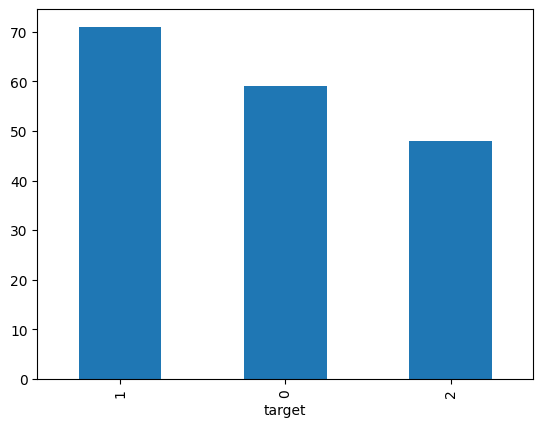

In [4]:
df['target'].value_counts().plot(kind = 'bar')

In [5]:
import seaborn as sns

import matplotlib.pyplot as plt

#Select specific features for pairplot

selected_features = ['alcohol', 'hue', 'color_intensity', 'target']

df_selected = df[selected_features]

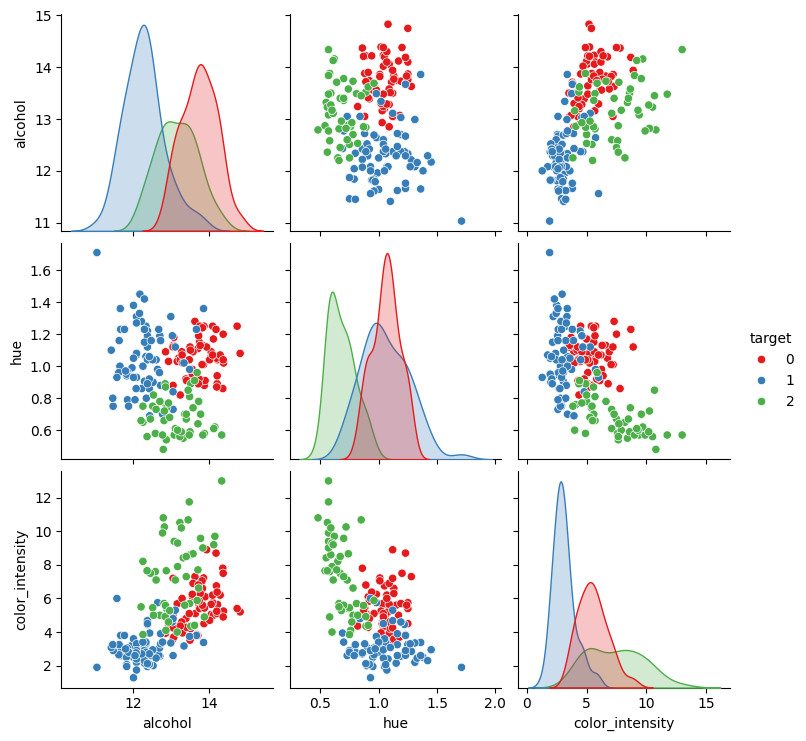

In [6]:
# Create scatter plots with hue = target

sns.pairplot(df_selected, hue='target', palette='Set1', diag_kind='kde')

#Show the plot

plt.show()

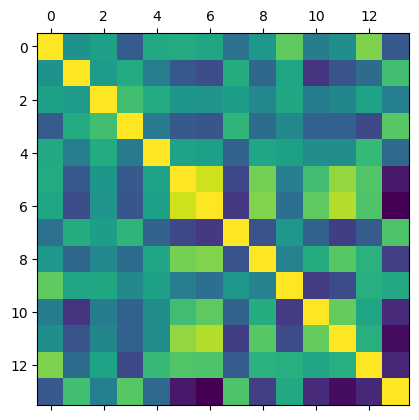

In [7]:
plt.matshow(df.corr())

plt.show()

In [8]:
#Standardize the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#Check the mean and standard deviation

print(f"Mean: {np.mean(X_scaled, axis=0)}")

print(f"Standard Deviation: {np.std(X_scaled, axis=0)}")

Mean: [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17]
Standard Deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [14]:
#Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#Display the explained variance ratio

print(f"Explained variance ratio (first 2 components): {pca.explained_variance_ratio_}")

Explained variance ratio (first 2 components): [0.36198848 0.1920749 ]


In [15]:
#Combine the PCA results and target labels into a DataFrame

wine_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

#Add the target labels to the DataFrame

wine_df['Target'] = y

#Display the first few rows of the DataFrame

print(wine_df.head())

        PC1       PC2  Target
0  3.316751  1.443463       0
1  2.209465 -0.333393       0
2  2.516740  1.031151       0
3  3.757066  2.756372       0
4  1.008908  0.869831       0


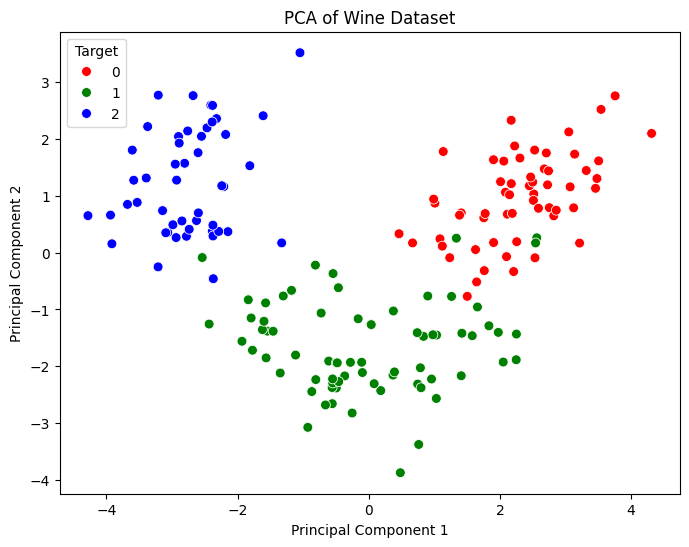

In [16]:
import seaborn as sns

#Create the scatter plot

plt.figure(figsize=(8,6))

sns.scatterplot(data=wine_df,

                x='PC1',

                y='PC2',

                hue='Target',

                palette=['red', 'green', 'blue'],

                s=50)



plt.title('PCA of Wine Dataset')

plt.xlabel('Principal Component 1')

plt.ylabel('Principal Component 2')



plt.show()

In [17]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score



# Split original dataset (without PCA)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train logistic regression on full dataset

clf_full = LogisticRegression(max_iter=5000)

clf_full.fit(X_train, y_train)

y_pred_full = clf_full.predict(X_test)

accuracy_full = accuracy_score(y_test, y_pred_full)



# Train logistic regression on PCA-reduced dataset

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

clf_pca = LogisticRegression(max_iter=5000)

clf_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = clf_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)



print(f"Accuracy with all 13 features: {accuracy_full:.2f}")

print(f"Accuracy with only 2 PCA components: {accuracy_pca:.2f}")

#Try PCA with only 1 component

pca_1d = PCA(n_components=1)

X_pca_1d = pca_1d.fit_transform(X_scaled)



# Train logistic regression on the 1D PCA-transformed data

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_1d, y, test_size=0.2, random_state=42)

clf_pca_1d = LogisticRegression(max_iter=5000)

clf_pca_1d.fit(X_train_pca, y_train_pca)

y_pred_pca_1d = clf_pca_1d.predict(X_test_pca)

accuracy_pca_1d = accuracy_score(y_test_pca, y_pred_pca_1d)



print(f"Accuracy with only 1 PCA component: {accuracy_pca_1d:.2f}")

Accuracy with all 13 features: 1.00
Accuracy with only 2 PCA components: 1.00
Accuracy with only 1 PCA component: 0.86


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


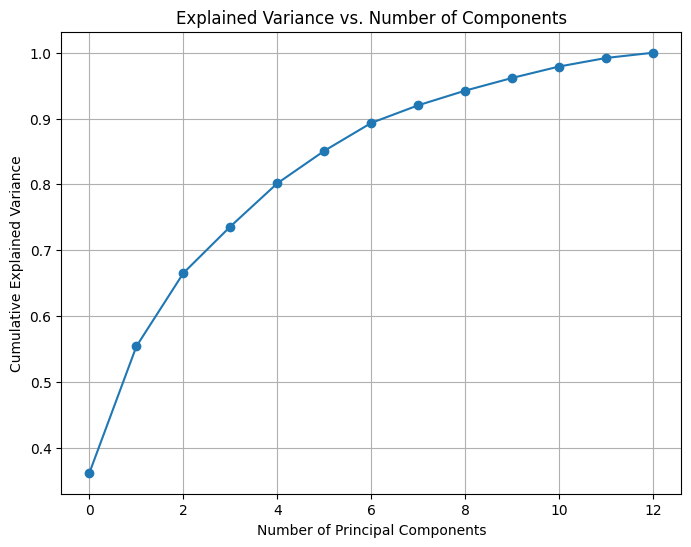

In [18]:
import numpy as np

#Fit PCA without specifying n_components

pca_full = PCA().fit(X_scaled)

#plot cumulative explained variance

plt.figure(figsize=(8,6))

plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')

plt.xlabel('Number of Principal Components')

plt.ylabel('Cumulative Explained Variance')

plt.title('Explained Variance vs. Number of Components')

plt.grid()

plt.show()

In [19]:
# Reconstruct data from PCA (using only 2 components)

X_reconstructed = pca.inverse_transform(X_pca)

#Compare original vs reconstructed data

print("Original Data (First Row):\n", X_scaled[0])

print("Reconstructed Data (First Row):\n", X_reconstructed[0])

from sklearn.metrics import mean_squared_error

#Compute MSE

mse = mean_squared_error(X_scaled, X_reconstructed)

print(f"Reconstruction Error (MSE): {mse:.4f}")

Original Data (First Row):
 [ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
  1.01300893]
Reconstructed Data (First Row):
 [ 1.17683758 -0.48854671  0.44943066 -0.80905314  0.90346271  1.40287378
  1.39791791 -0.9486178   1.09629808  0.47110942  0.58106277  1.01020946
  1.47780928]
Reconstruction Error (MSE): 0.4459
